In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ICT_DSA.python/Datasets/adult_dataset.csv")



In [3]:
# first 5 rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
# dataset shape
df.shape

(48842, 15)

In [5]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
# checking null values
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [7]:
# replace ? with NaN
df.replace('?', np.nan, inplace=True)

In [8]:
# checking missing values again
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [9]:
# numerical columns
num_cols = ['age','fnlwgt','education-num',
            'capital-gain','capital-loss','hours-per-week']

In [10]:
# categorical columns
cat_cols = ['workclass','education','marital-status','occupation',
            'relationship','race','sex','native-country']

In [11]:
# fill missing values in numerical columns

for col in num_cols:

    df[col].fillna(df[col].median(),
                   inplace=True)

/tmp/ipykernel_1003/1246775084.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),


In [12]:
# fill missing values in categorical columns

for col in cat_cols:

    df[col].fillna(df[col].mode()[0],
                   inplace=True)

/tmp/ipykernel_1003/2032048294.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],


In [13]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


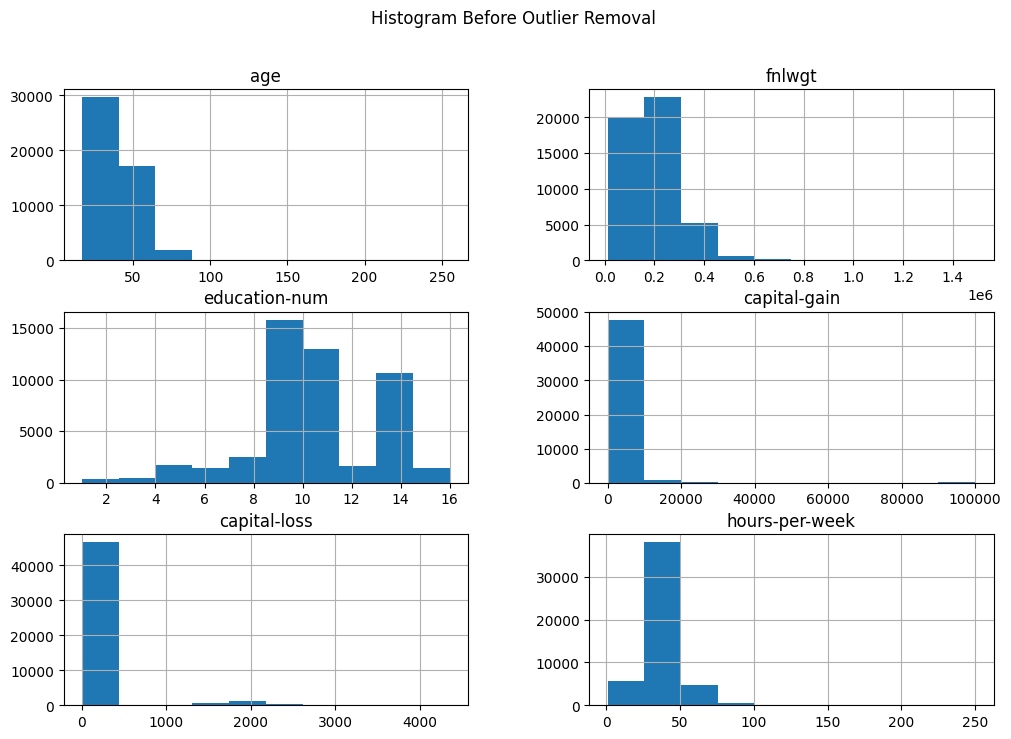

In [14]:
# histogram before outlier removal

df[num_cols].hist(figsize=(12,8))

plt.suptitle('Histogram Before Outlier Removal')

plt.show()

In [15]:
# storing income column separately

income_actual = df['income']

In [16]:
# removing irrelevant columns

df.drop(['income',
         'fnlwgt',
         'education'],
         axis=1,
         inplace=True)

# dataset after removing columns

df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States
1,50.0,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States
2,38.0,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States
3,53.0,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States
4,28.0,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba


In [17]:
# label encoding

# label encoding is used to convert categorical/text columns
# into numerical values because machine learning algorithms
# cannot understand string data directly

# KMeans clustering works only with numerical data,
# so categorical columns are encoded before model training

# label encoding

le = LabelEncoder()

cat_cols = ['workclass',
            'marital-status',
            'occupation',
            'relationship',
            'race',
            'sex',
            'native-country']

for col in cat_cols:

    df[col] = le.fit_transform(df[col])

In [18]:
# dataset after encoding

df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,6,13,4,0,1,4,1,2174,0,40.0,38
1,50.0,5,13,2,3,0,4,1,0,0,13.0,38
2,38.0,3,9,0,5,1,4,1,0,0,40.0,38
3,53.0,3,7,2,5,0,2,1,0,0,40.0,38
4,28.0,3,13,2,9,5,2,0,0,0,40.0,4


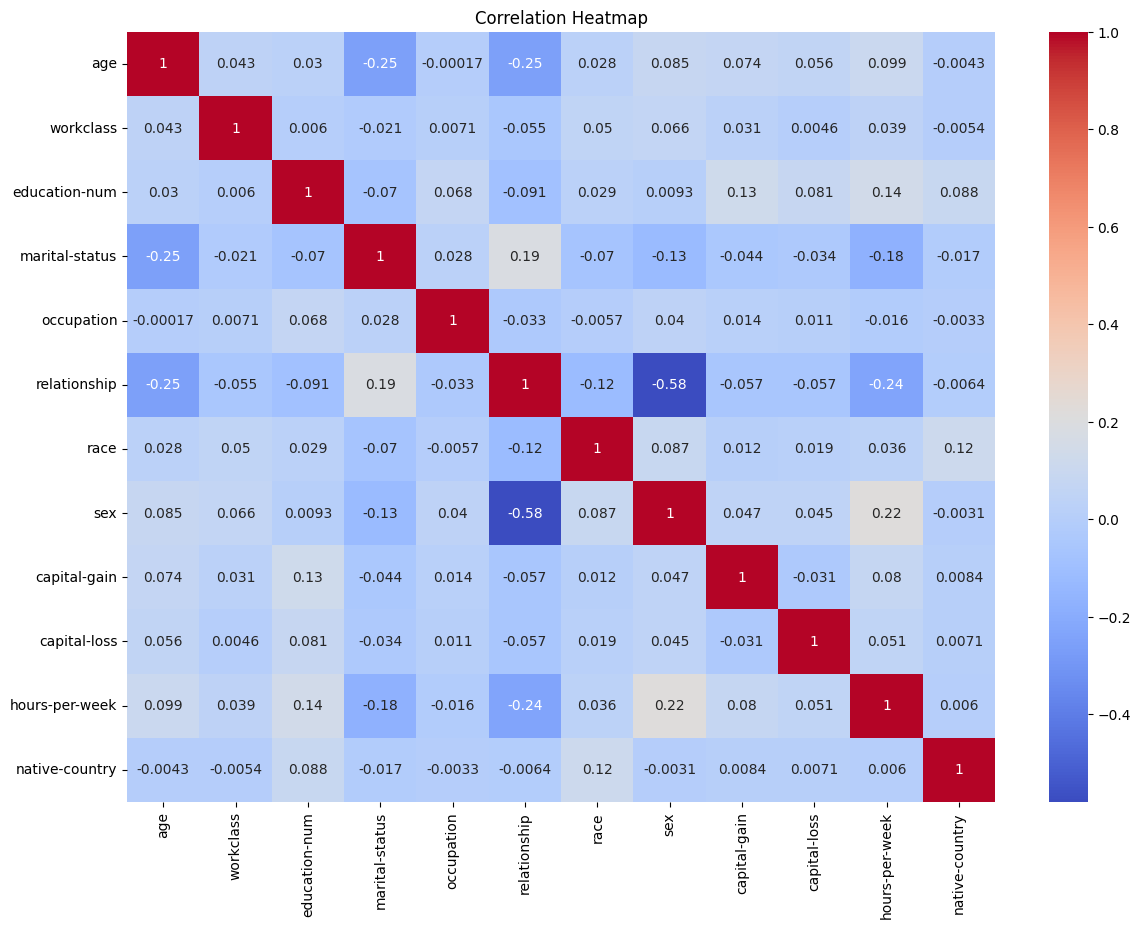

In [19]:
# correlation heatmap
## plotting correlation heatmap to visualize relationships between features

plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

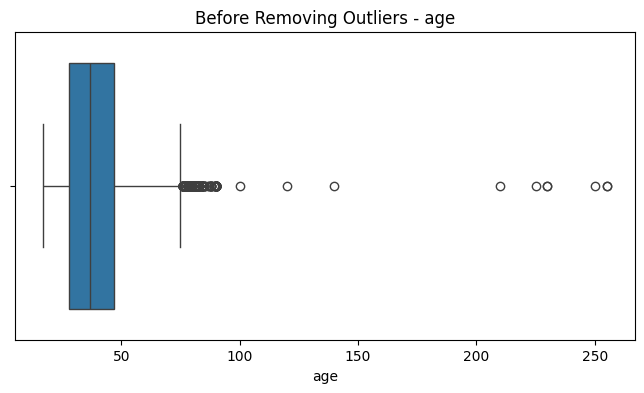

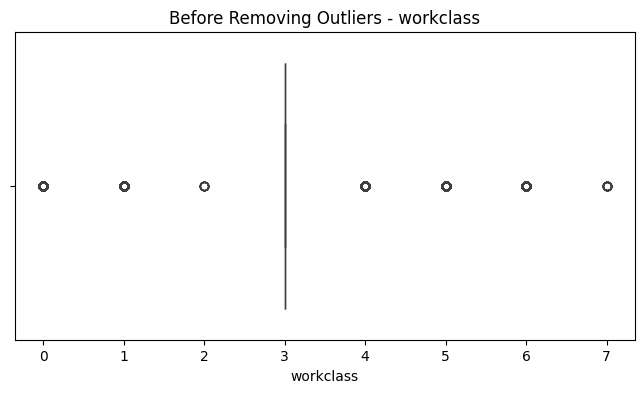

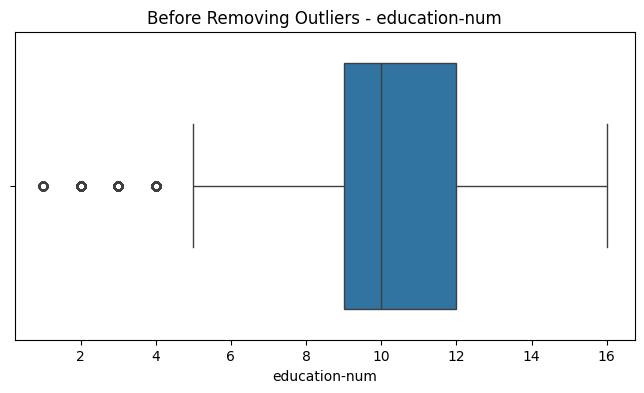

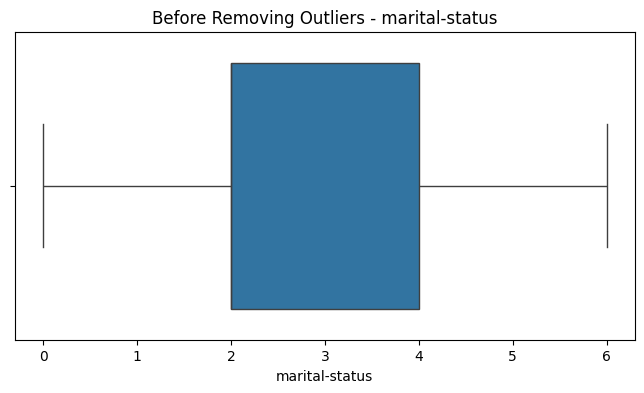

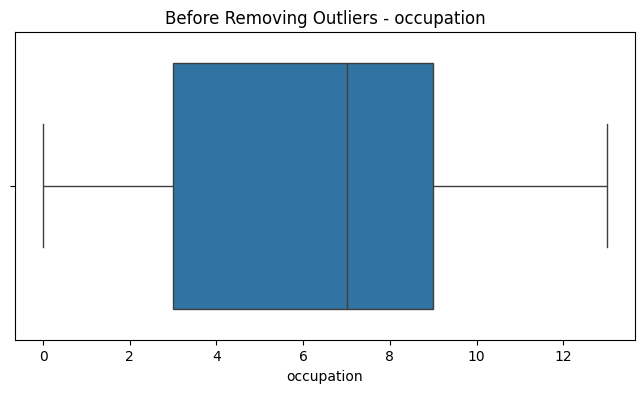

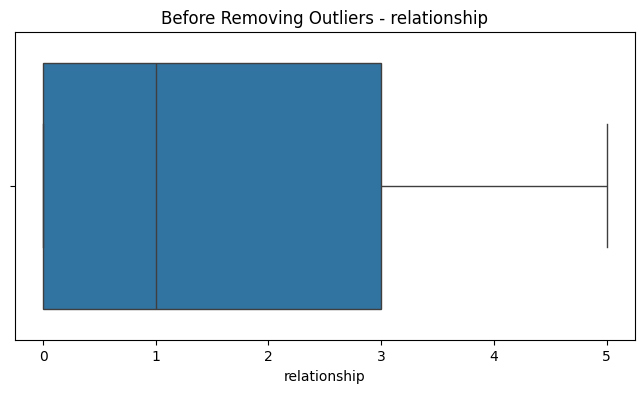

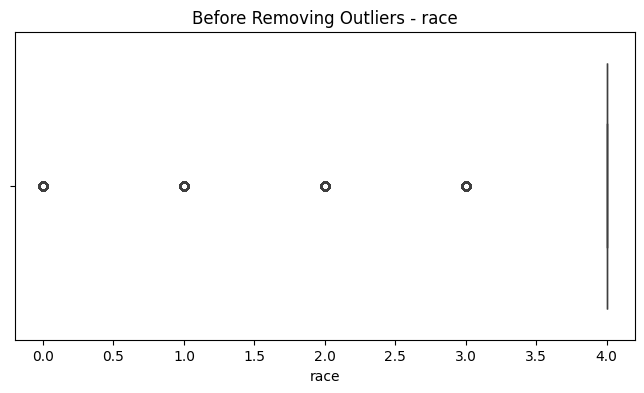

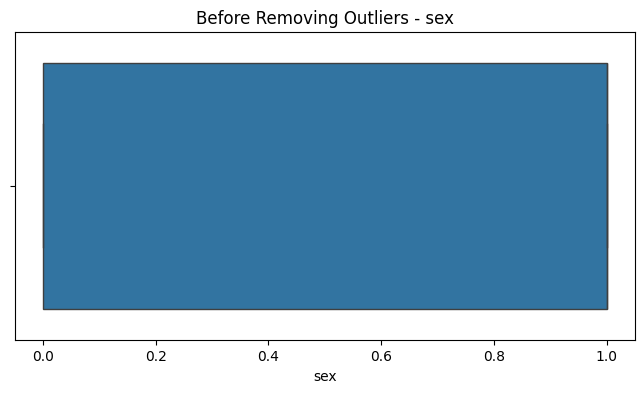

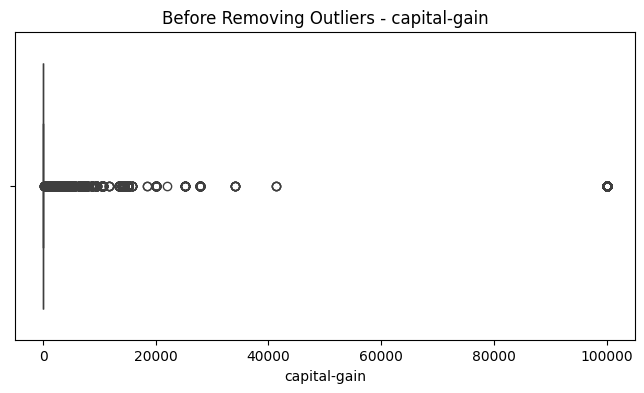

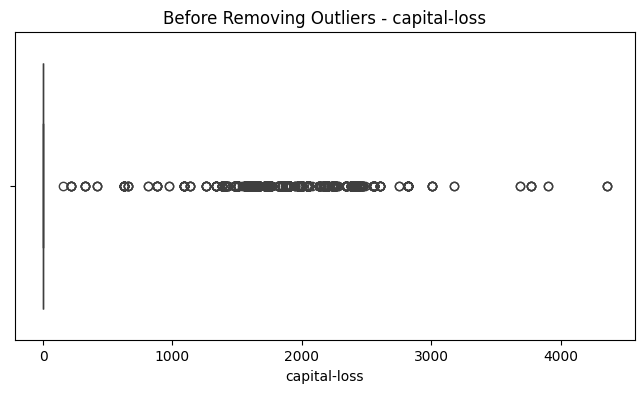

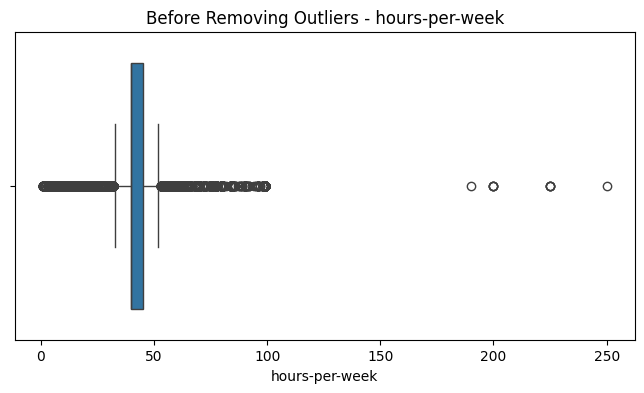

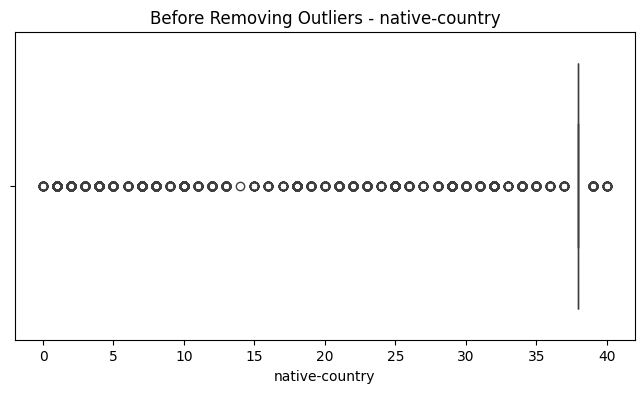

In [20]:
# boxplot before removing outliers

for col in df.columns:

    if col != 'Cluster':

        plt.figure(figsize=(8,4))

        sns.boxplot(x=df[col])

        plt.title(f'Before Removing Outliers - {col}')

        plt.show()

In [21]:
# numerical columns after dropping columns

num_cols = ['age',
            'education-num',
            'capital-gain',
            'capital-loss',
            'hours-per-week']


# removing outliers using IQR method

for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) &
            (df[col] <= upper)]


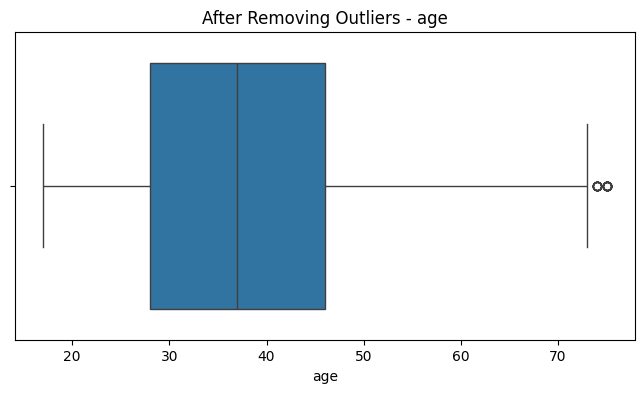

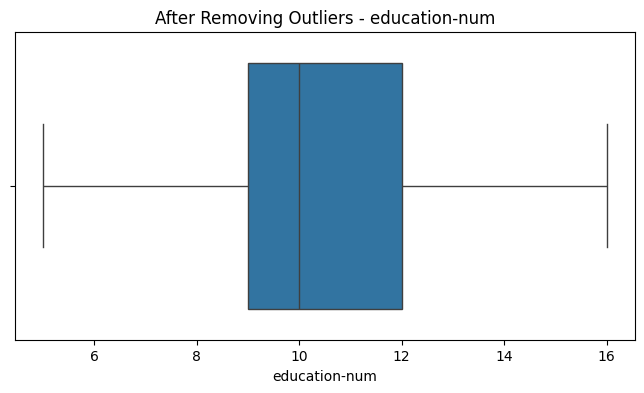

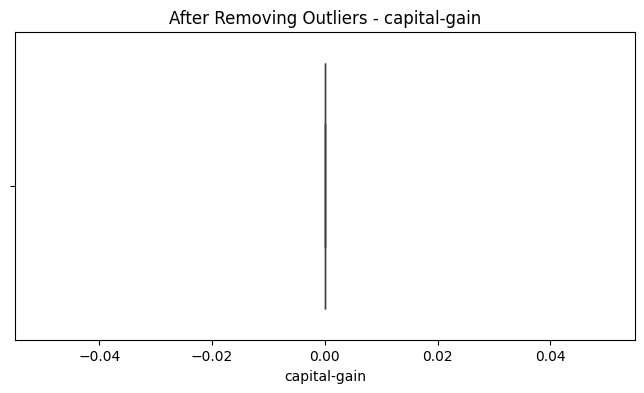

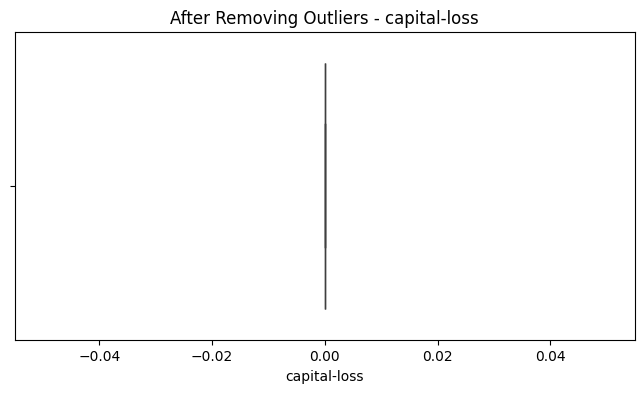

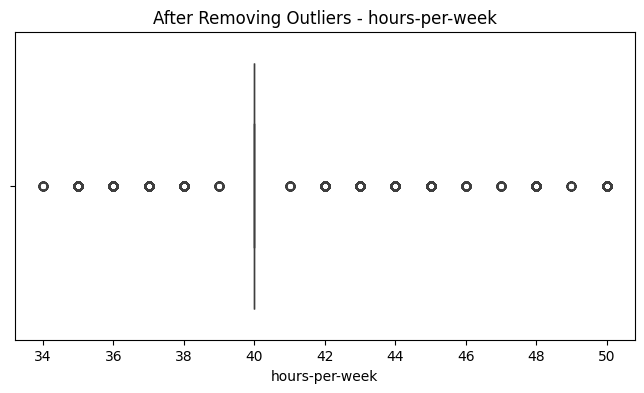

In [22]:
# boxplot after removing outliers

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f'After Removing Outliers - {col}')

    plt.show()

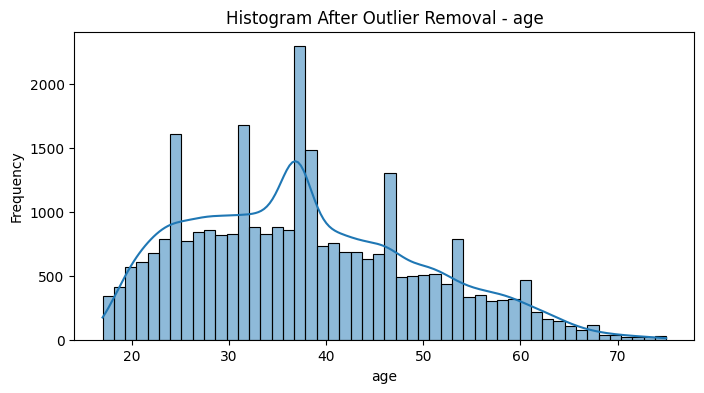

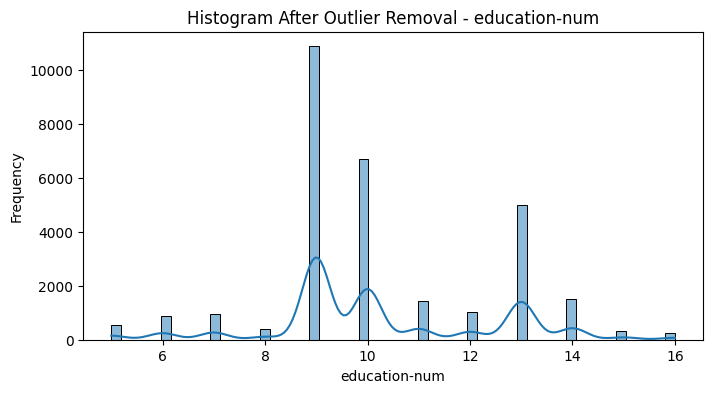

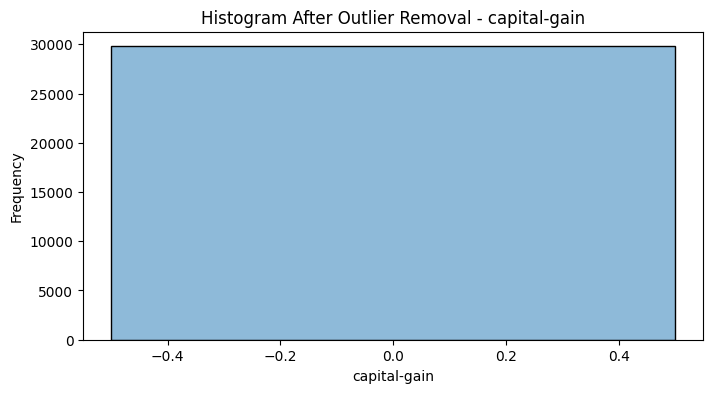

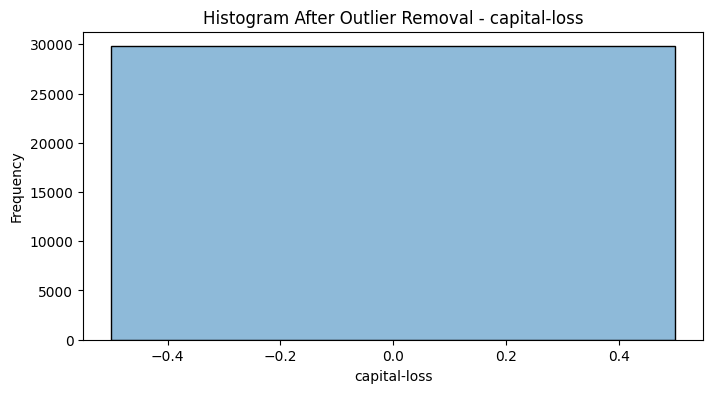

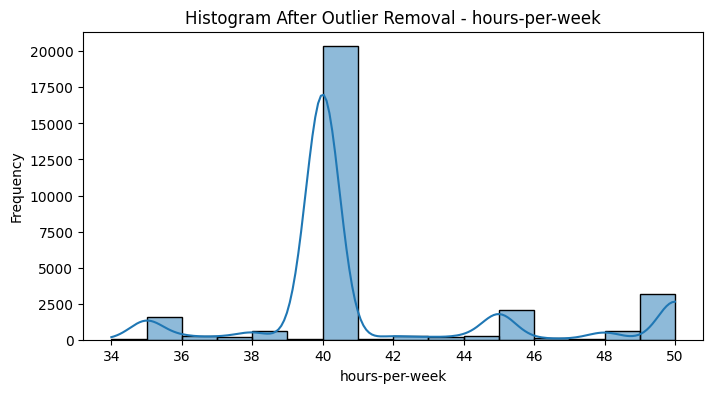

In [23]:
# histogram after outlier removal using seaborn

for col in num_cols:

    plt.figure(figsize=(8,4))
    sns.histplot(df[col],
                 kde=True)
    plt.title(f'Histogram After Outlier Removal - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [24]:
# feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [25]:
# scaled data shape

X_scaled.shape

(29789, 12)

In [26]:
# PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# PCA shape
X_pca.shape

(29789, 2)

In [27]:
# elbow method
# finding best K value for KMeans clustering

wcss = []

for i in range(1,11):

    k_means_model = KMeans(n_clusters=i,
                           n_init=5,
                           random_state=42)

    k_means_model.fit(X_scaled)

    wcss_value = k_means_model.inertia_

    wcss.append(wcss_value)

In [28]:
wcss   # checking wcss values

[297889.9999999998,
 254734.2814191496,
 232899.26316398376,
 212757.5248470126,
 198827.70305832507,
 178034.8674336591,
 168545.12105044787,
 160246.97585650746,
 153534.26932894767,
 148429.40378708916]

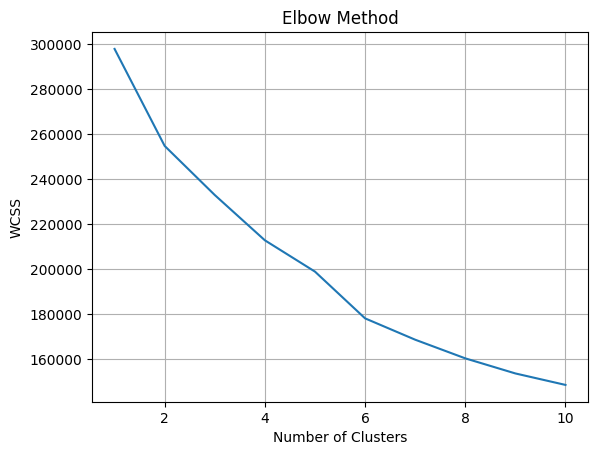

In [29]:
# elbow plot

plt.plot(range(1,11),
         wcss,
         )

# title
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [42]:
kmeans = KMeans(n_clusters=4, n_init=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [43]:
# add income column back

df['income'] = income_actual

In [30]:
# optimum number of clusters = 4

k_means = KMeans(n_clusters=4,
                 n_init=5,
                 random_state=42)

# model building

k_means.fit(X_scaled)

KMeans(n_clusters=4, n_init=5, random_state=42)

In [31]:
# model prediction

cluster_label = k_means.predict(X_scaled)
cluster_label

array([2, 2, 0, ..., 3, 1, 2], dtype=int32)

In [32]:
# adding cluster column

df['Cluster'] = cluster_label

df.head()

# checking rows in each cluster

df['Cluster'].value_counts()

,count
Cluster,
2,13692
3,9137
1,5855
0,1105


In [33]:
# silhouette score

score = silhouette_score(X_scaled,
                         cluster_label)

print(score)

0.13616059068543637


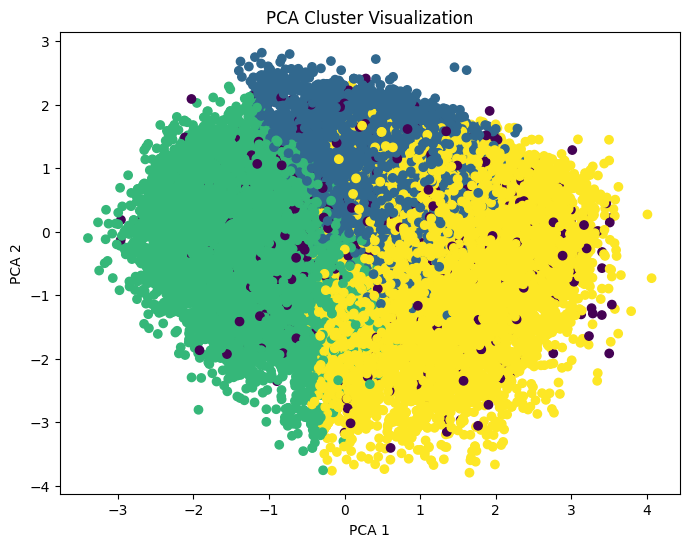

In [34]:
# PCA cluster visualization

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=df['Cluster'])

plt.xlabel('PCA 1')

plt.ylabel('PCA 2')

plt.title('PCA Cluster Visualization')

plt.show()

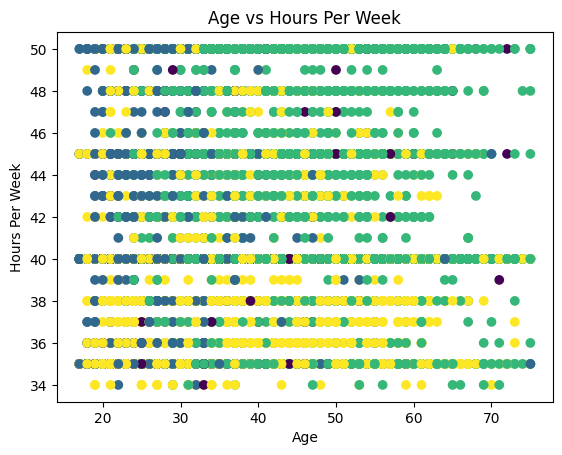

In [35]:
# age vs hours per week

plt.scatter(df['age'],
            df['hours-per-week'],
            c=df['Cluster'])

plt.xlabel('Age')

plt.ylabel('Hours Per Week')

plt.title('Age vs Hours Per Week')

plt.show()

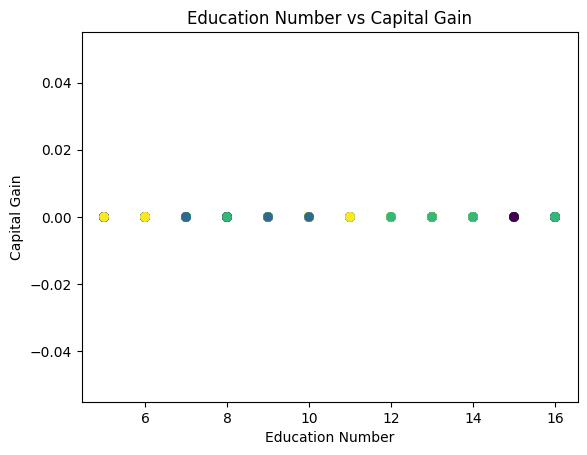

In [36]:
# education number vs capital gain

plt.scatter(df['education-num'],
            df['capital-gain'],
            c=df['Cluster'])

plt.xlabel('Education Number')

plt.ylabel('Capital Gain')

plt.title('Education Number vs Capital Gain')

plt.show()

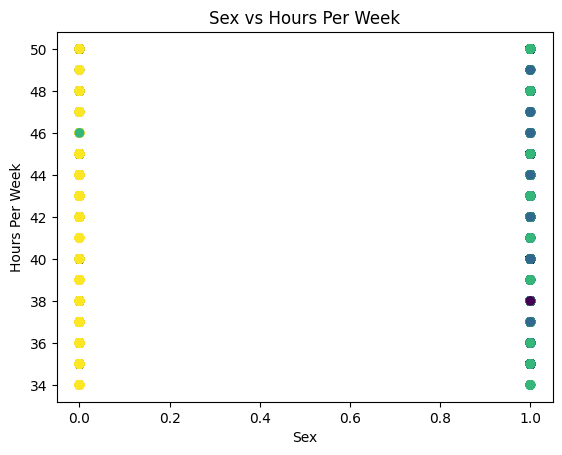

In [37]:
# sex vs hours per week

plt.scatter(df['sex'],
            df['hours-per-week'],
            c=df['Cluster'])

plt.xlabel('Sex')

plt.ylabel('Hours Per Week')

plt.title('Sex vs Hours Per Week')

plt.show()

In [38]:
# 11. AGGLOMERATIVE CLUSTERING
# ============================================================
from sklearn.cluster import KMeans, AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4)

df['Agglomerative_Cluster'] = agg.fit_predict(X_scaled)

print(df['Agglomerative_Cluster'].value_counts())

Agglomerative_Cluster
0    15805
1     8480
3     3776
2     1728
Name: count, dtype: int64


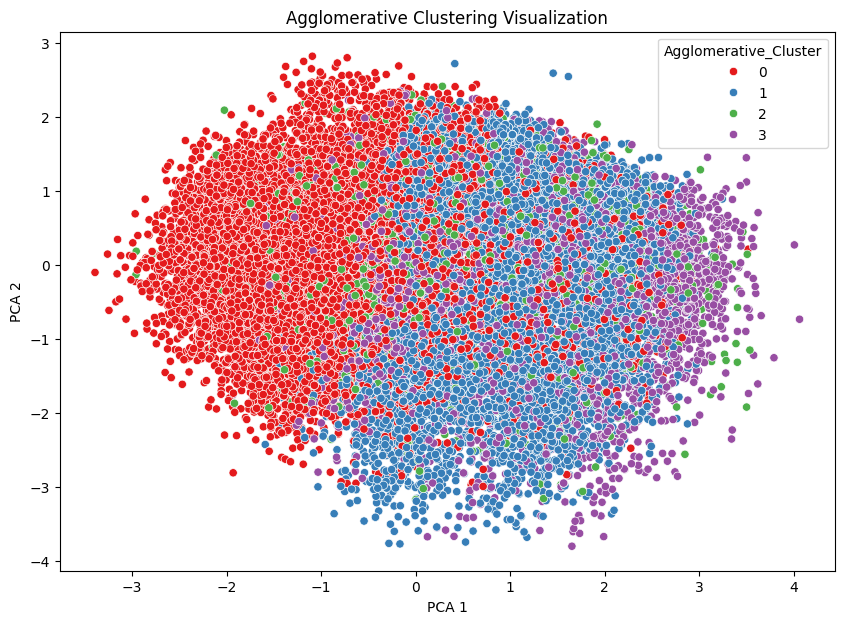

In [39]:
# AGGLOMERATIVE CLUSTER VISUALIZATION


plt.figure(figsize=(10,7))

sns.scatterplot(x=X_pca[:,0],
                y=X_pca[:,1],
                hue=df['Agglomerative_Cluster'],
                palette='Set1')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.title('Agglomerative Clustering Visualization')

plt.show()


In [44]:
# compare cluster distribution with actual income

pd.crosstab(df['KMeans_Cluster'],
            df['income'])

income,<=50K,<=50K.,>50K,>50K.
KMeans_Cluster,,,,
0,578,268,183,76
1,3729,1930,142,54
2,5812,2926,3284,1670
3,5551,2771,551,264


In [40]:
#CLUSTER PROFILING
cluster_profile = df.groupby('Cluster').mean()

print(cluster_profile)

               age  workclass  education-num  marital-status  occupation  \
Cluster                                                                    
0        38.504072   3.135747      10.602715        2.608145    6.136652   
1        28.791802   3.028181       9.817763        3.980188    6.276003   
2        42.622115   3.096041      10.382632        1.773298    6.202600   
3        36.282259   2.941119      10.237605        2.818212    5.568786   

         relationship      race       sex  capital-gain  capital-loss  \
Cluster                                                                 
0            1.337557  3.098643  0.673303           0.0           0.0   
1            2.053629  3.572502  0.999829           0.0           0.0   
2            0.270450  3.807333  0.975606           0.0           0.0   
3            2.800591  3.504433  0.002298           0.0           0.0   

         hours-per-week  native-country  Agglomerative_Cluster  
Cluster                                

###  INTERPRETATION OF CLUSTERS


CLUSTER 0
-----------
- Middle aged working population
- Moderate education level
- Standard working hours

Policy Suggestion:
Upskilling programs and job transition support


CLUSTER 1
-----------
- Highly educated professionals
- Higher work hours
- Better financial indicators

Policy Suggestion:
Tax reform and investment awareness programs


CLUSTER 2
-----------
- Lower income and low education population
- Reduced working hours

Policy Suggestion:
Financial aid and vocational training


CLUSTER 3
-----------
- Older or semi-retired population
- Lower workforce participation

Policy Suggestion:
Healthcare support and pension schemes
"""

CONCLUSION
===========

1. Unsupervised learning techniques were used successfully
   to identify hidden socioeconomic groups.

2. PCA helped visualize high-dimensional data.

3. KMeans and Agglomerative clustering identified
   meaningful demographic segments.

4. Education level, age, work hours and capital gain/loss
   strongly influenced clustering.

5. The discovered groups can help government and policy
   makers design:

   - Welfare schemes
   - Employment programs
   - Financial inclusion strategies
   - Tax reforms